# kin_00 — Movement QC: noise vs. real tongue movement classification

`kin_01_population.ipynb`'s quality filter requires `out_duration > 0.05s`, which
removes 61% of all segmented movements. That's a round-number heuristic with no
documented justification. This notebook asks whether there is a statistically
and physically grounded breakpoint between **spurious detections** (e.g. a
single frame where tracking confidence jitters above the 0.90 mask threshold,
immediately followed by a dropout) and **real tongue movements**.

**This notebook is diagnostic only.** It produces a recommendation, not an
applied filter — no new column or file is persisted; `kin_01` is not modified.

**Pipeline:**
1. Load `all_tongue_movements`, unfiltered
2. Univariate distributions of whole-movement QC fields
3. Gaussian-mixture breakpoint on log(duration), cross-checked on log(n_datapoints)
4. Cross-validate the breakpoint against n_datapoints / dropped_frames_pct
5. Physically-grounded floor (independent of the GMM)
6. Peak-velocity-vs-distance implausibility check
7. Bout-fragmentation check (are short movements tracking-gap fragments of an adjacent real one?)
8. Synthesize a candidate `is_likely_noise` flag and map it onto `out_duration`
9. Recommendation

## 1. Setup

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm as _norm, spearmanr, chi2_contingency
from sklearn.mixture import GaussianMixture
from statsmodels.nonparametric.smoothers_lowess import lowess

from plotstyle import apply_style, PALETTE, style_ax, save_fig
apply_style()

In [2]:
if Path("/root/capsule").exists():
    ENV       = "codeocean"
    SCRATCH   = Path("/root/capsule/scratch")
    FOR_LOCAL = SCRATCH / "for_local"
else:
    ENV       = "local"
    FOR_LOCAL = Path("/Users/mib/Documents/Code/kinematics_analysis/data/for_local")
    SCRATCH   = FOR_LOCAL.parent

FIG_DIR  = SCRATCH / "figures" / "kin_00_movement_qc"
SAVE_FIG = False
print(f"ENV={ENV}")

ENV=local


## 2. Load data

Full, **unfiltered** dataset — this notebook exists to evaluate whether a filter is justified, so kin_01's quality filter is not applied here.

In [3]:
if ENV == "codeocean":
    movements_path = SCRATCH / "all_tongue_movements_04022026" / "all_tongue_movements_04022026.parquet"
else:
    movements_path = FOR_LOCAL / "all_tongue_movements_04022026.parquet"

all_tongue_movements = pd.read_parquet(movements_path)
print("Shape:", all_tongue_movements.shape)
print("Sessions:", all_tongue_movements["session"].nunique())

Shape: (246359, 49)
Sessions: 44


## 3. Why whole-movement fields, not `out_*`

`out_duration`/`out_peak_velocity`/`out_total_distance` are computed by this
repo's `compute_outbound_metrics()`, which truncates each movement to the
frames between its start and the frame of maximum distance from the jaw (the
"outbound phase"). That truncation is itself a modeling choice, and it can
make an otherwise-normal movement look spuriously short if its peak excursion
happens early.

The question here — *did the upstream segmenter (`segment_movements_trimnans`,
which tolerates up to 10 consecutive dropped frames at 500 Hz) find a real
tracking event at all* — is a property of the **whole movement**, not its
outbound-truncated subset. So sections 4-8 work on `duration`, `n_datapoints`,
`dropped_frames_pct`, `peak_velocity`, and `total_distance`. Section 9 maps the
resulting noise/real label back onto `out_duration` to directly evaluate
`kin_01`'s actual filter.

## 4. Univariate distributions of whole-movement QC fields

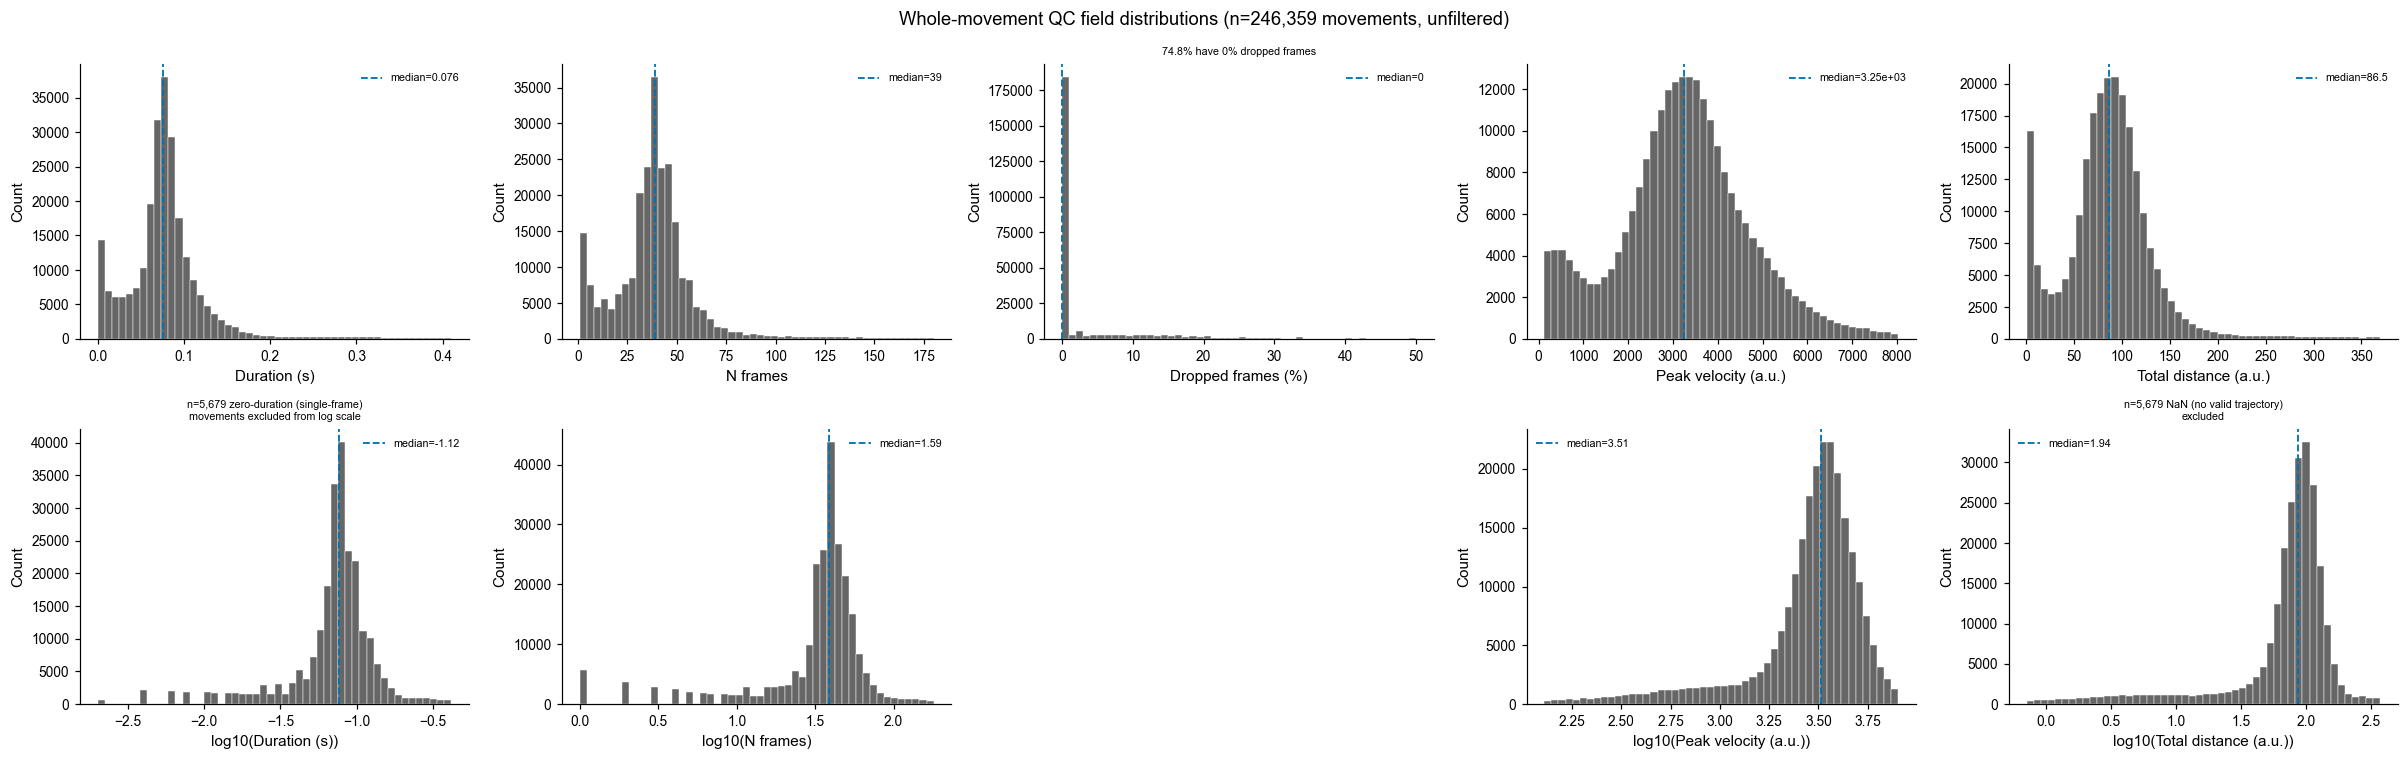

In [4]:
def _qc_hist(ax, vals, label, log=False, color=None):
    color = color or PALETTE["neutral"]
    vals = np.asarray(vals, dtype=float)
    vals = vals[~np.isnan(vals)]
    if log:
        vals = vals[vals > 0]
        vals = np.log10(vals)
        label = f"log10({label})"
    lo, hi = np.nanpercentile(vals, 1), np.nanpercentile(vals, 99)
    vals_c = vals[(vals >= lo) & (vals <= hi)]
    ax.hist(vals_c, bins=50, color=color, edgecolor="white", linewidth=0.3)
    med = np.median(vals)
    ax.axvline(med, color=PALETTE["neg"], lw=1.2, ls="--", label=f"median={med:.3g}")
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.legend(fontsize=7)
    style_ax(ax)

fig, axes = plt.subplots(2, 5, figsize=(22, 7))

dur = all_tongue_movements["duration"].to_numpy()
n_zero_dur = int((dur == 0).sum())
_qc_hist(axes[0, 0], dur, "Duration (s)")
_qc_hist(axes[1, 0], dur, "Duration (s)", log=True)
axes[1, 0].set_title(f"n={n_zero_dur:,} zero-duration (single-frame)\nmovements excluded from log scale", fontsize=7)

ndp = all_tongue_movements["n_datapoints"].to_numpy()
_qc_hist(axes[0, 1], ndp, "N frames")
_qc_hist(axes[1, 1], ndp, "N frames", log=True)

dfp = all_tongue_movements["dropped_frames_pct"].to_numpy()
_qc_hist(axes[0, 2], dfp, "Dropped frames (%)")
axes[1, 2].set_visible(False)
pct_zero_drop = 100 * np.nanmean(dfp == 0)
axes[0, 2].set_title(f"{pct_zero_drop:.1f}% have 0% dropped frames", fontsize=7)

pv = all_tongue_movements["peak_velocity"].to_numpy()
_qc_hist(axes[0, 3], pv, "Peak velocity (a.u.)")
_qc_hist(axes[1, 3], pv, "Peak velocity (a.u.)", log=True)

td = all_tongue_movements["total_distance"].to_numpy()
n_nan_td = int(np.isnan(td).sum())
_qc_hist(axes[0, 4], td, "Total distance (a.u.)")
_qc_hist(axes[1, 4], td, "Total distance (a.u.)", log=True)
axes[1, 4].set_title(f"n={n_nan_td:,} NaN (no valid trajectory)\nexcluded", fontsize=7)

fig.suptitle(f"Whole-movement QC field distributions (n={len(all_tongue_movements):,} movements, unfiltered)")
plt.tight_layout()
save_fig(fig, "qc_univariate_distributions", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 5. Gaussian-mixture breakpoint on log(duration)

Mixture BIC by n_components: {1: np.float64(572326.9), 2: np.float64(397727.7), 3: np.float64(396971.3)}
Best by BIC: k=3

k used for noise/real labeling: 3
  component 0 [NOISE]: mean=17.9 ms  weight=0.139
  component 1 [real]: mean=80.3 ms  weight=0.699
  component 2 [real]: mean=98.9 ms  weight=0.162

GMM noise/real crossover (duration): 35.4 ms (0.0354 s)
Physical floor (10 frames @ 500 Hz): 20.0 ms



GMM crossover on log(n_datapoints): 23.4 frames (~46.9 ms) vs duration-based crossover 35.4 ms


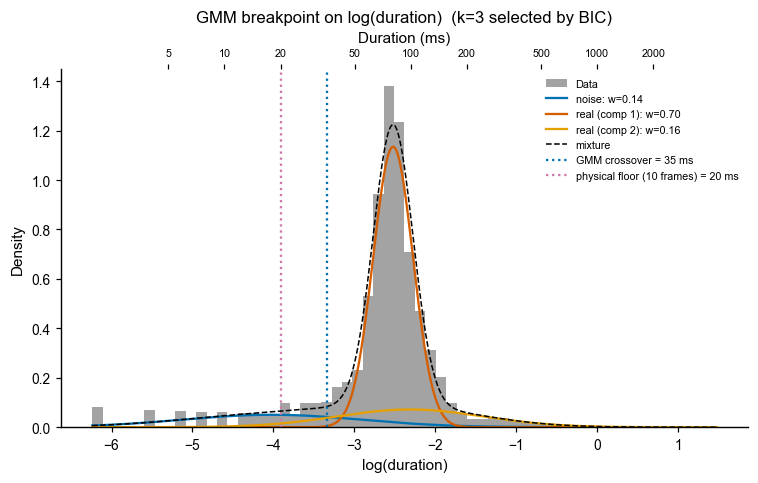

In [5]:
# Physical floor (justified in section 7) — defined here so it can be drawn
# on this plot for direct comparison against the data-driven GMM crossover.
PHYSICAL_FLOOR_FRAMES = 10
PHYSICAL_FLOOR_S = PHYSICAL_FLOOR_FRAMES / 500.0

dur_pos = all_tongue_movements.loc[all_tongue_movements["duration"] > 0, "duration"].to_numpy()
X = np.log(dur_pos).reshape(-1, 1)

bics = {}
fits = {}
for k in (1, 2, 3):
    gm_k = GaussianMixture(n_components=k, random_state=42).fit(X)
    bics[k] = gm_k.bic(X)
    fits[k] = gm_k

best_k = min(bics, key=bics.get)
print("Mixture BIC by n_components:", {k: round(v, 1) for k, v in bics.items()})
print(f"Best by BIC: k={best_k}")

k_used = best_k if best_k > 1 else 2
gm = fits[k_used]
order = np.argsort(gm.means_.ravel())
noise_idx = order[0]

x_grid = np.linspace(X.min(), X.max(), 2000)
post = gm.predict_proba(x_grid.reshape(-1, 1))
noise_prob = post[:, noise_idx]
peak_i = np.argmax(noise_prob)
below = np.where(noise_prob[peak_i:] < 0.5)[0]
crossover_log = x_grid[peak_i + below[0]] if len(below) else np.nan
crossover_s = np.exp(crossover_log)

print(f"\nk used for noise/real labeling: {k_used}")
for k_i, i in enumerate(order):
    tag = "NOISE" if i == noise_idx else "real"
    print(f"  component {k_i} [{tag}]: mean={np.exp(gm.means_[i, 0]) * 1000:.1f} ms  weight={gm.weights_[i]:.3f}")
print(f"\nGMM noise/real crossover (duration): {crossover_s * 1000:.1f} ms ({crossover_s:.4f} s)")
print(f"Physical floor ({PHYSICAL_FLOOR_FRAMES} frames @ 500 Hz): {PHYSICAL_FLOOR_S * 1000:.1f} ms")

# Sensitivity check on log(n_datapoints)
ndp_all = all_tongue_movements["n_datapoints"].to_numpy().astype(float)
Xn = np.log(ndp_all).reshape(-1, 1)
gm_n = GaussianMixture(n_components=2, random_state=42).fit(Xn)
order_n = np.argsort(gm_n.means_.ravel())
noise_idx_n = order_n[0]
xg_n = np.linspace(Xn.min(), Xn.max(), 2000)
post_n = gm_n.predict_proba(xg_n.reshape(-1, 1))
noise_prob_n = post_n[:, noise_idx_n]
peak_i_n = np.argmax(noise_prob_n)
below_n = np.where(noise_prob_n[peak_i_n:] < 0.5)[0]
crossover_frames = np.exp(xg_n[peak_i_n + below_n[0]]) if len(below_n) else np.nan
print(f"\nGMM crossover on log(n_datapoints): {crossover_frames:.1f} frames "
      f"(~{crossover_frames / 500 * 1000:.1f} ms) vs duration-based crossover {crossover_s * 1000:.1f} ms")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(X.ravel(), bins=60, density=True, alpha=0.6, color=PALETTE["neutral"], label="Data")
y_mix = np.zeros_like(x_grid)
colors_k = [PALETTE["neg"], PALETTE["pos"], PALETTE["sig"]]
for k_i, i in enumerate(order):
    comp = gm.weights_[i] * _norm.pdf(x_grid, gm.means_[i, 0], np.sqrt(gm.covariances_[i, 0, 0]))
    y_mix += comp
    lbl = "noise" if i == noise_idx else f"real (comp {k_i})"
    ax.plot(x_grid, comp, color=colors_k[k_i % len(colors_k)], lw=1.5, label=f"{lbl}: w={gm.weights_[i]:.2f}")
ax.plot(x_grid, y_mix, "k--", lw=1, label="mixture")
ax.axvline(crossover_log, color=PALETTE["neg"], ls=":", lw=1.5,
           label=f"GMM crossover = {crossover_s * 1000:.0f} ms")
ax.axvline(np.log(PHYSICAL_FLOOR_S), color=PALETTE["accent"], ls=":", lw=1.5,
           label=f"physical floor (10 frames) = {PHYSICAL_FLOOR_S * 1000:.0f} ms")

s_ticks = [0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1, 2]
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
valid_ticks = [t for t in np.log(s_ticks) if X.min() <= t <= X.max()]
ax2.set_xticks(valid_ticks)
ax2.set_xticklabels([f"{np.exp(t) * 1000:.0f}" for t in valid_ticks], fontsize=7)
ax2.set_xlabel("Duration (ms)")
ax.set_xlabel("log(duration)")
ax.set_ylabel("Density")
ax.set_title(f"GMM breakpoint on log(duration)  (k={k_used} selected by BIC)")
ax.legend(fontsize=7)
style_ax(ax)
plt.tight_layout()
save_fig(fig, "gmm_duration_breakpoint", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 6. Cross-validate the breakpoint against n_datapoints / dropped_frames_pct

GMM-duration-flagged noise: 14.2% of movements


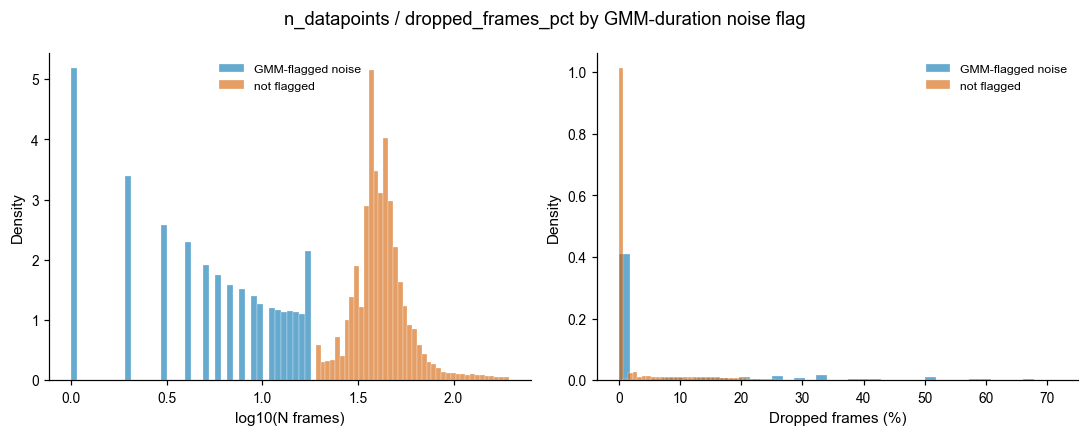

Spearman(noise_posterior, n_datapoints) = -0.547  (p=0.00e+00)
Spearman(noise_posterior, dropped_frames_pct) = 0.159  (p=0.00e+00)

                       n_datapoints  dropped_frames_pct
is_noise_gmm_duration                                  
False                          41.0                 0.0
True                            6.0                 0.0


In [6]:
df_qc = all_tongue_movements.copy()
df_qc["is_noise_gmm_duration"] = df_qc["duration"] < crossover_s

noise_post_all = np.full(len(df_qc), np.nan)
mask_pos = (df_qc["duration"] > 0).to_numpy()
noise_post_all[mask_pos] = gm.predict_proba(
    np.log(df_qc.loc[mask_pos, "duration"].to_numpy()).reshape(-1, 1)
)[:, noise_idx]
noise_post_all[~mask_pos] = 1.0  # zero-duration movements are certain noise
df_qc["noise_posterior_duration"] = noise_post_all

print(f"GMM-duration-flagged noise: {df_qc['is_noise_gmm_duration'].mean() * 100:.1f}% of movements")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, label, log in [
    (axes[0], "n_datapoints", "N frames", True),
    (axes[1], "dropped_frames_pct", "Dropped frames (%)", False),
]:
    for flag, color, lbl in [(True, PALETTE["neg"], "GMM-flagged noise"), (False, PALETTE["pos"], "not flagged")]:
        vals = df_qc.loc[df_qc["is_noise_gmm_duration"] == flag, col].dropna().to_numpy()
        if log:
            vals = vals[vals > 0]
            vals = np.log10(vals)
        lo, hi = np.nanpercentile(vals, 1), np.nanpercentile(vals, 99)
        vals_c = vals[(vals >= lo) & (vals <= hi)]
        ax.hist(vals_c, bins=40, color=color, alpha=0.6, label=lbl, edgecolor="white", linewidth=0.3, density=True)
    ax.set_xlabel(f"log10({label})" if log else label)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
    style_ax(ax)
fig.suptitle("n_datapoints / dropped_frames_pct by GMM-duration noise flag")
plt.tight_layout()
save_fig(fig, "qc_crossvalidation", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

for col in ("n_datapoints", "dropped_frames_pct"):
    rho, p = spearmanr(df_qc["noise_posterior_duration"], df_qc[col])
    print(f"Spearman(noise_posterior, {col}) = {rho:.3f}  (p={p:.2e})")

print()
print(df_qc.groupby("is_noise_gmm_duration")[["n_datapoints", "dropped_frames_pct"]].median())

## 7. Physically-grounded floor (independent of the GMM)

Numerical differentiation amplifies high-frequency noise — a long-standing
point in motion-tracking/biomechanics literature (Winter, *Biomechanics and
Motor Control of Human Movement*): velocity is a frame-to-frame position
derivative, so estimates built from very few samples are dominated by
tracking jitter rather than true kinematics. The upstream pipeline applies a
50 Hz, 4th-order Butterworth low-pass filter before differentiating (at
500 Hz sampling) — that cutoff implies an effective temporal resolution of
roughly 1/50 s = 20 ms = **10 frames** (`PHYSICAL_FLOOR_FRAMES`, defined in
section 5). Below that frame count, a "movement" sits inside the filter's own
smoothing window and its velocity/duration estimate is not trustworthy,
regardless of whether the GMM happens to call it noise or real.

In [7]:
pct_below_floor = (df_qc["n_datapoints"] < PHYSICAL_FLOOR_FRAMES).mean() * 100
print(f"{pct_below_floor:.1f}% of movements have < {PHYSICAL_FLOOR_FRAMES} frames "
      f"(physical floor = {PHYSICAL_FLOOR_S * 1000:.0f} ms)")
print(f"GMM crossover (duration)   = {crossover_s * 1000:.1f} ms")
print(f"Physical floor (10 frames) = {PHYSICAL_FLOOR_S * 1000:.1f} ms")
print(f"-> {'GMM crossover is ABOVE the physical floor' if crossover_s > PHYSICAL_FLOOR_S else 'GMM crossover is AT/BELOW the physical floor'} "
      f"(physical floor is {'the binding constraint' if PHYSICAL_FLOOR_S > crossover_s else 'subsumed by the GMM crossover'})")

9.7% of movements have < 10 frames (physical floor = 20 ms)
GMM crossover (duration)   = 35.4 ms
Physical floor (10 frames) = 20.0 ms
-> GMM crossover is ABOVE the physical floor (physical floor is subsumed by the GMM crossover)


## 8. Peak-velocity-vs-distance implausibility check

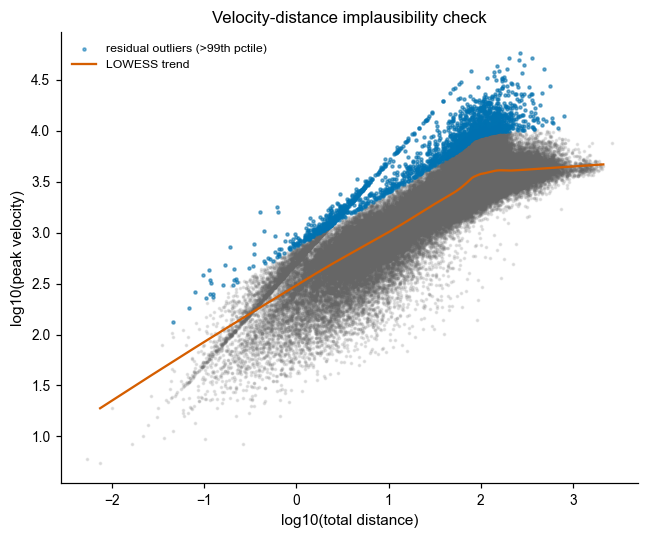

51.8% of velocity-residual outliers are also GMM-duration-flagged as noise
Single-frame movements (n=5,679) peak_velocity: median=827, max=2142827


In [8]:
sub = df_qc.dropna(subset=["total_distance", "peak_velocity"]).copy()
log_d = np.log10(sub["total_distance"].to_numpy())
log_v = np.log10(sub["peak_velocity"].to_numpy())

rng = np.random.default_rng(42)
samp_idx = rng.choice(len(sub), size=min(30000, len(sub)), replace=False)
order_fit = np.argsort(log_d[samp_idx])
lo_fit = lowess(log_v[samp_idx][order_fit], log_d[samp_idx][order_fit], frac=0.2, return_sorted=True)

pred_v = np.interp(log_d, lo_fit[:, 0], lo_fit[:, 1])
resid = log_v - pred_v
resid_thresh = np.nanpercentile(resid, 99)
is_velocity_outlier = resid > resid_thresh
sub["is_velocity_outlier"] = is_velocity_outlier

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(log_d, log_v, s=2, alpha=0.15, color=PALETTE["neutral"], rasterized=True)
ax.scatter(log_d[is_velocity_outlier], log_v[is_velocity_outlier], s=4, alpha=0.5,
           color=PALETTE["neg"], rasterized=True, label="residual outliers (>99th pctile)")
ax.plot(lo_fit[:, 0], lo_fit[:, 1], color=PALETTE["pos"], lw=1.5, label="LOWESS trend")
ax.set_xlabel("log10(total distance)")
ax.set_ylabel("log10(peak velocity)")
ax.legend(fontsize=8)
ax.set_title("Velocity-distance implausibility check")
style_ax(ax)
plt.tight_layout()
save_fig(fig, "velocity_distance_implausibility", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

overlap = sub.loc[is_velocity_outlier, "is_noise_gmm_duration"].mean() * 100
print(f"{overlap:.1f}% of velocity-residual outliers are also GMM-duration-flagged as noise")

single_frame_pv = df_qc.loc[df_qc["n_datapoints"] == 1, "peak_velocity"]
print(f"Single-frame movements (n={len(single_frame_pv):,}) peak_velocity: "
      f"median={single_frame_pv.median():.0f}, max={single_frame_pv.max():.0f}")

## 9. Bout-fragmentation check

In [9]:
g = df_qc.sort_values(["session", "trial", "start_time"], na_position="last").copy()
gb = g.groupby(["session", "trial"], dropna=False)
g["next_start"] = gb["start_time"].shift(-1)
g["prev_end"]   = gb["end_time"].shift(1)
g["gap_to_next"]   = g["next_start"] - g["end_time"]
g["gap_from_prev"] = g["start_time"] - g["prev_end"]

n_nan_trial = int(g["trial"].isna().sum())
print(f"{n_nan_trial:,} movements have no trial assignment (kept via groupby dropna=False)")
print(f"gap_to_next defined for {g['gap_to_next'].notna().sum():,} / {len(g):,} movements")

GAP_THRESH = 0.04  # ~2x the upstream max_dropped_frames=10 (20ms) NaN-tolerance
g["adjacent"] = (g["gap_to_next"] < GAP_THRESH) | (g["gap_from_prev"] < GAP_THRESH)

adj_rate = g.groupby("is_noise_gmm_duration")["adjacent"].mean() * 100
print(f"\n% adjacent to another movement within {GAP_THRESH * 1000:.0f} ms, by noise flag:")
print(adj_rate.round(1))

ct = pd.crosstab(g["is_noise_gmm_duration"], g["adjacent"])
chi2, p, dof, _ = chi2_contingency(ct)
print(f"\nchi2={chi2:.1f}, p={p:.2e}")
print(ct)

24,188 movements have no trial assignment (kept via groupby dropna=False)
gap_to_next defined for 231,588 / 246,359 movements

% adjacent to another movement within 40 ms, by noise flag:
is_noise_gmm_duration
False    16.0
True     43.9
Name: adjacent, dtype: float64

chi2=14599.4, p=0.00e+00
adjacent                False  True 
is_noise_gmm_duration               
False                  177654  33773
True                    19614  15318


## 10. Synthesize a candidate `is_likely_noise` flag (in-memory only)

Overall: 14.3% of movements flagged as likely noise
count    44.0
mean     14.7
std       8.2
min       2.6
25%       7.6
50%      16.4
75%      19.7
max      33.2
Name: is_likely_noise, dtype: float64


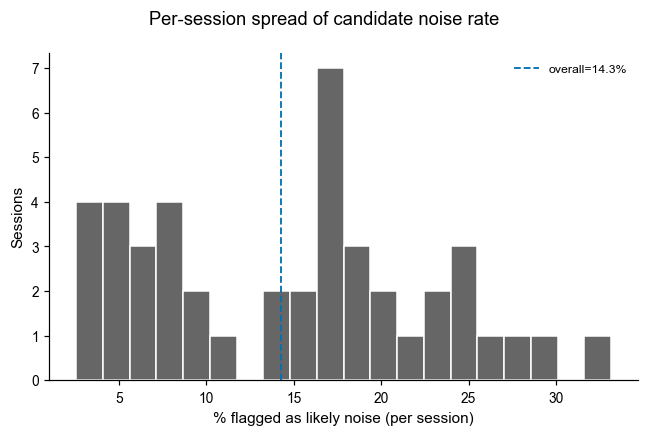

In [10]:
df_qc["is_likely_noise"] = (
    (df_qc["duration"] == 0)
    | (df_qc["n_datapoints"] < PHYSICAL_FLOOR_FRAMES)
    | (df_qc["duration"] < crossover_s)
)

pct_flagged = df_qc["is_likely_noise"].mean() * 100
print(f"Overall: {pct_flagged:.1f}% of movements flagged as likely noise")

sess_rate = df_qc.groupby("session")["is_likely_noise"].mean() * 100
print(sess_rate.describe().round(1))

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(sess_rate, bins=20, color=PALETTE["neutral"], edgecolor="white")
ax.axvline(pct_flagged, color=PALETTE["neg"], ls="--", lw=1.2, label=f"overall={pct_flagged:.1f}%")
ax.set_xlabel("% flagged as likely noise (per session)")
ax.set_ylabel("Sessions")
ax.legend(fontsize=8)
style_ax(ax)
fig.suptitle("Per-session spread of candidate noise rate")
plt.tight_layout()
save_fig(fig, "noise_flag_session_spread", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 11. Map the candidate flag onto `out_duration`

This is the field `kin_01` actually filters on — does the whole-movement-based noise label agree with the current `out_duration > 0.05` heuristic?

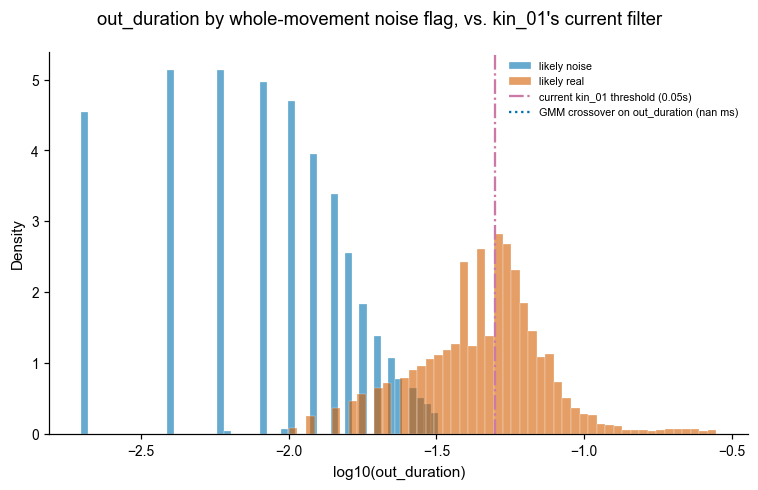

(n=18,515 zero out_duration rows excluded from log scale; 81.6% of them are also flagged is_likely_noise)

Current filter (out_duration<=0.05 removed) removal rate: 61.3%
New criterion (is_likely_noise) removal rate:               14.3%
Current filter misses (keeps despite flagged noise):        0.0% of all movements
Current filter over-removes (drops despite flagged real):   47.1% of all movements


In [11]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for flag, color, lbl in [(True, PALETTE["neg"], "likely noise"), (False, PALETTE["pos"], "likely real")]:
    vals = df_qc.loc[df_qc["is_likely_noise"] == flag, "out_duration"].to_numpy()
    vals = vals[vals > 0]
    vals = np.log10(vals)
    lo, hi = np.nanpercentile(vals, 1), np.nanpercentile(vals, 99)
    vals_c = vals[(vals >= lo) & (vals <= hi)]
    ax.hist(vals_c, bins=50, color=color, alpha=0.6, label=lbl, density=True, edgecolor="white", linewidth=0.3)
ax.axvline(np.log10(0.05), color=PALETTE["accent"], ls="-.", lw=1.5, label="current kin_01 threshold (0.05s)")

out_pos = df_qc.loc[df_qc["out_duration"] > 0, "out_duration"].to_numpy()
Xo = np.log(out_pos).reshape(-1, 1)
gm_o = GaussianMixture(n_components=2, random_state=42).fit(Xo)
order_o = np.argsort(gm_o.means_.ravel())
noise_idx_o = order_o[0]
xg_o = np.linspace(Xo.min(), Xo.max(), 2000)
post_o = gm_o.predict_proba(xg_o.reshape(-1, 1))
noise_prob_o = post_o[:, noise_idx_o]
peak_i_o = np.argmax(noise_prob_o)
below_o = np.where(noise_prob_o[peak_i_o:] < 0.5)[0]
crossover_out_s = np.exp(xg_o[peak_i_o + below_o[0]]) if len(below_o) else np.nan
ax.axvline(np.log10(crossover_out_s), color=PALETTE["neg"], ls=":", lw=1.5,
           label=f"GMM crossover on out_duration ({crossover_out_s * 1000:.0f} ms)")

ax.set_xlabel("log10(out_duration)")
ax.set_ylabel("Density")
ax.legend(fontsize=7)
fig.suptitle("out_duration by whole-movement noise flag, vs. kin_01's current filter")
style_ax(ax)
plt.tight_layout()
save_fig(fig, "out_duration_vs_noise_flag", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

n_zero_out = int((df_qc["out_duration"] == 0).sum())
zero_out_all_noise = df_qc.loc[df_qc["out_duration"] == 0, "is_likely_noise"].mean()
print(f"(n={n_zero_out:,} zero out_duration rows excluded from log scale; "
      f"{zero_out_all_noise * 100:.1f}% of them are also flagged is_likely_noise)")

current_filter_keeps = df_qc["out_duration"] > 0.05
misses = (df_qc["is_likely_noise"] & current_filter_keeps).mean() * 100
overremoves = (~df_qc["is_likely_noise"] & ~current_filter_keeps).mean() * 100
print(f"\nCurrent filter (out_duration<=0.05 removed) removal rate: {(~current_filter_keeps).mean() * 100:.1f}%")
print(f"New criterion (is_likely_noise) removal rate:               {df_qc['is_likely_noise'].mean() * 100:.1f}%")
print(f"Current filter misses (keeps despite flagged noise):        {misses:.1f}% of all movements")
print(f"Current filter over-removes (drops despite flagged real):   {overremoves:.1f}% of all movements")

## 12. Recommendation

**Findings (local 44-session dataset, n=246,359 movements):**

- A 3-component GMM on `log(duration)` is preferred over 1 or 2 components by
  BIC (572,327 → 397,728 → 396,971). The lowest-mean component (mean 17.9 ms,
  weight 0.14) separates cleanly from the two higher components (80.3 ms and
  98.9 ms — plausibly "short flick" vs. "full lick" sub-populations within the
  "real" class). The noise/real posterior crossover is **35.4 ms**.
- That crossover is corroborated by an independent fit on `log(n_datapoints)`
  (crossover ≈ 23.4 frames ≈ 46.9 ms — same order of magnitude, ~1.3x).
- It sits *above* the physically-grounded floor implied by the upstream 50 Hz
  filter (10 frames / 20 ms) — so the floor is subsumed by the GMM crossover,
  not the binding constraint on its own.
- Flagged-noise movements have a much lower median frame count (6 vs. 39
  overall) and the noise posterior correlates with `n_datapoints` (ρ=-0.55)
  more than with `dropped_frames_pct` (ρ=0.16) — short "movements" look like
  too-few-frames detections, not gap-riddled real ones.
- Velocity/distance implausibility is a real but partially independent
  signal: only 51.8% of velocity-residual outliers overlap with the
  GMM-duration-flagged group. Single-frame movements (n=5,679) have a median
  `peak_velocity` of 827 (max 2.14M) despite `total_distance` being undefined
  for them — a clear mistracking signature.
- Bout-fragmentation is supported: GMM-flagged-noise movements sit within
  40 ms of an adjacent movement **43.9%** of the time, vs. 16.0% for
  not-flagged movements (χ²=14,599, p≈0) — short movements are disproportionately
  fragments adjacent to a real one, consistent with the upstream segmenter's
  10-frame NaN-tolerance occasionally splitting one real lick into two pieces.
- The synthesized `is_likely_noise` flag (`duration==0` OR `n_datapoints<10`
  OR `duration<35.4ms`) flags **14.3%** of movements overall, with a per-session
  range of 2.6%-33.2% (median 16.4%) — no single session dominates, so this
  isn't a session-specific tracking artifact.
- Mapped onto `out_duration`: the current `kin_01` filter (`out_duration>0.05`)
  removes 61.3% of movements, vs. 14.3% for the new criterion. The current
  filter **misses 0.0%** of flagged noise (it never keeps something the new
  criterion calls noise) but **over-removes 47.1%** of movements the new
  criterion would keep as real — i.e. it's not wrong about what's noise, it's
  just far more aggressive than necessary, because `out_duration`'s
  outbound-phase truncation shortens movements well beyond what whole-movement
  fields show.

**Recommendation:** replace the flat `out_duration > 0.05` floor in `kin_01`
with a whole-movement-based criterion — e.g. require `n_datapoints >= 10`
*and* `duration > ~0.035s` (or reuse `is_likely_noise` from this notebook,
recomputed on whichever dataset is current) — applied before/instead of
relying on the outbound-truncated `out_duration`. This would retain roughly
47 additional percentage points of movements that are plausibly real,
while still excluding single-frame detections and movements below the
upstream filter's physical resolution. **This is a recommendation only — not
applied to `kin_01` in this notebook.**